In [1]:
import sys
print(sys.executable)

/data/jyothimsis/myenv/bin/python


### 1 . Environment setup

In [2]:

import sys
import os

# Prevent transformers from loading torchvision
os.environ["TRANSFORMERS_NO_TOUCH_VISION"] = "1"
import re
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    DEVICE = "cpu"
    print("PyTorch not installed in this environment yet — install requirements above before training.")

print("Device:", DEVICE)


Device: cuda


LABELS = ["Favour", "Against", "None"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}

CONFIG = {
    "max_length": 160,
    "train_batch_size": 16,
    "eval_batch_size": 32,
    "num_epochs": 4,
    "learning_rate": 2e-5,
    "val_size": 0.15,
    "seed": SEED,
    "data_dir": "./data",
    "out_dir": "./outputs",
}

os.makedirs(CONFIG["data_dir"], exist_ok=True)
os.makedirs(CONFIG["out_dir"], exist_ok=True)

MODEL_REGISTRY = {
    "mbert":    "bert-base-multilingual-cased",
    "xlmr":     "xlm-roberta-base",
    "qwen":     "Qwen/Qwen2.5-0.5B",   # swap for Qwen2.5-1.5B/3B if you have more GPU memory
}
print(MODEL_REGISTRY)


### 3 . Configuration

In [3]:
LABELS = ["Favour", "Against", "None"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}

CONFIG = {
    "max_length": 160,
    "train_batch_size": 16,
    "eval_batch_size": 32,
    "num_epochs": 4,
    "learning_rate": 2e-5,
    "val_size": 0.15,
    "seed": SEED,
    "data_dir": "./data",
    "out_dir": "./outputs",
}

os.makedirs(CONFIG["data_dir"], exist_ok=True)
os.makedirs(CONFIG["out_dir"], exist_ok=True)

MODEL_REGISTRY = {
    "mbert":    "bert-base-multilingual-cased",
    "xlmr":     "xlm-roberta-base",
    "qwen":     "Qwen/Qwen2.5-0.5B",   # swap for Qwen2.5-1.5B/3B if you have more GPU memory
}
print(MODEL_REGISTRY)


{'mbert': 'bert-base-multilingual-cased', 'xlmr': 'xlm-roberta-base', 'qwen': 'Qwen/Qwen2.5-0.5B'}


### 3 . Data Collection

In [4]:
hi_test = pd.read_csv( "datasets/Hindi_500_test data.csv")

bn_test = pd.read_csv("datasets/Bangla_500_test data.csv")

In [5]:


print("Hindi test set:", hi_test.shape)
print("Bangla test set:", bn_test.shape)

hi_test.head(3)


Hindi test set: (500, 2)
Bangla test set: (500, 2)


,ID,COMMENT
0,1,बिल नाई एक वैज्ञानिक नहीं हैं। वह एक यांत्रिक ...
1,2,ऑनलाइन कक्षाओं के लिए और कौन उपस्थित है?
2,3,शाकाहारियों को इतना परेशान करने वाला क्यों होत...


In [6]:
bn_test.head(3)

,ID,COMMENT
0,1,"পৃথিবীর নৃত্য এবং অনন্ত আকাশের মধ্যে, ফিসফিস ক..."
1,2,"ধন্যবাদ, আপনার করা সমস্ত কিছুর জন্য এবং আপনি য..."
2,3,এটি বায়ুমণ্ডলে কার্বন ডাই-অক্সাইডের ২৫০ ডিগ্র...


In [7]:
semeval=pd.read_csv(
    "datasets/SemEval_Climate.csv"
)
gwsd=pd.read_csv(
    "datasets/GWSD.csv"
)


In [8]:
print("Semval_Climate training dataset:", semeval.shape)
print("GWSD training dataset:", gwsd.shape)



Semval_Climate training dataset: (395, 4)
GWSD training dataset: (2300, 18)


In [9]:
semeval.head(3)

,ID,Target,Tweet,Stance
0,614,Climate Change is a Real Concern,"We cant deny it, its really happening. #SemST",FAVOR
1,615,Climate Change is a Real Concern,RT @cderworiz: Timelines are short. Strategy m...,FAVOR
2,616,Climate Change is a Real Concern,SO EXCITING! Meaningful climate change action ...,FAVOR


In [10]:
gwsd.head(3)

,Unnamed: 0,round,batch,sent_id,sentence,worker_0,worker_1,worker_2,worker_3,worker_4,worker_5,worker_6,worker_7,disagree,agree,neutral,guid,in_held_out_test
0,0,1,0,s0,Global warming is a hoax.,disagrees,disagrees,disagrees,disagrees,disagrees,disagrees,disagrees,disagrees,NaN,NaN,NaN,1_0_s0,False
1,1,1,0,s1,Alarming levels of sea level rise are predicte...,neutral,neutral,neutral,agrees,agrees,neutral,neutral,agrees,NaN,NaN,NaN,1_0_s1,False
2,2,1,0,s2,"Over the past several years, the United States...",neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,NaN,NaN,NaN,1_0_s2,False


### 3 . Label harmonization

In [11]:
import os
import pandas as pd

gwsd_path = "datasets/GWSD.csv"

if os.path.exists(gwsd_path):
    gwsd_raw = pd.read_csv(gwsd_path)

    # Create dataframe with the text column
    gwsd_df = gwsd_raw[["sentence"]].copy()
    gwsd_df.rename(columns={"sentence": "text"}, inplace=True)

    # Compute the hard label
    def get_label(row):
        votes = {
            "Favour": row["agree"],
            "Against": row["disagree"],
            "None": row["neutral"],
        }
        return max(votes, key=votes.get)

    gwsd_df["label"] = gwsd_raw.apply(get_label, axis=1)

print("GWSD hard-labelled rows:", len(gwsd_df))
print(gwsd_df["label"].value_counts(dropna=False))

GWSD hard-labelled rows: 2300
label
Favour     1027
None        873
Against     400
Name: count, dtype: int64


In [12]:
SEMEVAL_MAP = {"FAVOR": "Favour", "AGAINST": "Against", "NONE": "None"}

semeval_df = pd.DataFrame(columns=["text", "label"])
if len(semeval):
    semeval_df = semeval.rename(columns={"Tweet": "text"}).copy()
    semeval_df["label"] = semeval_df["Stance"].map(SEMEVAL_MAP)
    semeval_df = semeval_df.dropna(subset=["label"])[["text", "label"]]

print("SemEval climate rows:", len(semeval_df))
semeval_df["label"].value_counts()


SemEval climate rows: 395


label
Favour     212
None       168
Against     15
Name: count, dtype: int64

In [13]:
print(gwsd_df.columns)
print(semeval_df.columns)

Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')


In [14]:
gwsd_df.head(3)

,text,label
0,Global warming is a hoax.,Favour
1,Alarming levels of sea level rise are predicte...,Favour
2,"Over the past several years, the United States...",Favour


In [15]:
semeval_df.head(3)

,text,label
0,"We cant deny it, its really happening. #SemST",Favour
1,RT @cderworiz: Timelines are short. Strategy m...,Favour
2,SO EXCITING! Meaningful climate change action ...,Favour


In [16]:
en_train_df = pd.concat(
    [gwsd_df, semeval_df],
    ignore_index=True
)

en_train_df = (
    en_train_df
    .dropna(subset=["text", "label"])
    .drop_duplicates(subset=["text"])
    .reset_index(drop=True)
)

print("Combined English training set:", en_train_df.shape)
print(en_train_df["label"].value_counts())

display(en_train_df.head())

Combined English training set: (2442, 2)
label
None       1040
Favour      990
Against     412
Name: count, dtype: int64


,text,label
0,Global warming is a hoax.,Favour
1,Alarming levels of sea level rise are predicte...,Favour
2,"Over the past several years, the United States...",Favour
3,Global warming is happening and it will be dan...,Favour
4,Some icebergs are cute.,Favour


In [17]:
en_train_df.to_csv("datasets/train_en.csv",
    index=False
)

print("Saved as train_en.csv")

Saved as train_en.csv


### 5 . Preprocessing and Cleaning

In [18]:
import re
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
MULTISPACE_RE = re.compile(r"\s+")

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = text.replace("\n", " ").replace("\t", " ")
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

en_train_df["text"] = en_train_df["text"].apply(clean_text)
hi_test["COMMENT"] = hi_test["COMMENT"].apply(clean_text)
bn_test["COMMENT"] = bn_test["COMMENT"].apply(clean_text)

en_train_df = en_train_df[en_train_df["text"].str.len() > 0].reset_index(drop=True)
print(en_train_df.shape)
en_train_df.head(3)


(2442, 2)


,text,label
0,Global warming is a hoax.,Favour
1,Alarming levels of sea level rise are predicte...,Favour
2,"Over the past several years, the United States...",Favour


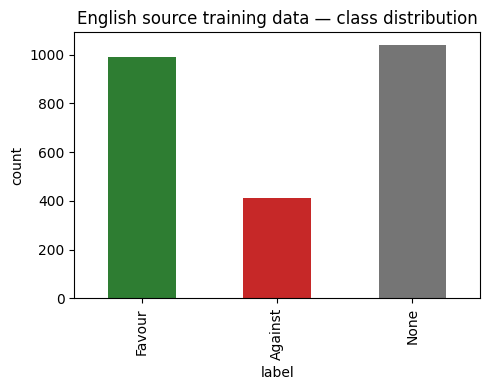

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
en_train_df["label"].value_counts().reindex(LABELS).plot(kind="bar", ax=ax, color=["#2e7d32", "#c62828", "#757575"])
ax.set_title("English source training data — class distribution")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


### 6. Cross lingual and adaptation

In [20]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm.auto import tqdm

NLLB_LANG_CODES = {
    "hi": "hin_Deva",
    "bn": "ben_Beng"
}

def load_nllb_translator(src_lang="eng_Latn"):
    model_name = "facebook/nllb-200-distilled-600M"
    tok = AutoTokenizer.from_pretrained(model_name, src_lang=src_lang)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(DEVICE)
    return tok, model

def translate_batch(texts, tok, model, tgt_lang, batch_size=16, max_length=160):
    outputs = []

    for i in tqdm(
        range(0, len(texts), batch_size),
        desc=f"Translating to {tgt_lang}"
    ):
        batch = texts[i:i + batch_size]

        enc = tok(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        ).to(DEVICE)

        gen = model.generate(
            **enc,
            forced_bos_token_id=tok.convert_tokens_to_ids(tgt_lang),
            max_length=max_length,
        )

        outputs.extend(tok.batch_decode(gen, skip_special_tokens=True))

    return outputs

print("Translation function defined.")

Translation function defined.


In [21]:
# --- Cache translated data so this expensive step runs once ---
hi_train_path = os.path.join(CONFIG["data_dir"], "train_hi_translated.csv")
bn_train_path = os.path.join(CONFIG["data_dir"], "train_bn_translated.csv")

if os.path.exists(hi_train_path) and os.path.exists(bn_train_path):
    hi_train_df = pd.read_csv(hi_train_path)
    bn_train_df = pd.read_csv(bn_train_path)
    print("Loaded cached translated training sets.")
else:
    print("Cached translations not found yet. Run the translation cell above once you have GPU + "
          "internet access, then save with:")
    print('  hi_train_df.to_csv(hi_train_path, index=False)')
    print('  bn_train_df.to_csv(bn_train_path, index=False)')
    # Placeholders so the rest of the notebook still runs structurally offline:
    hi_train_df = en_train_df.assign(lang="hi")
    bn_train_df = en_train_df.assign(lang="bn")


Cached translations not found yet. Run the translation cell above once you have GPU + internet access, then save with:
  hi_train_df.to_csv(hi_train_path, index=False)
  bn_train_df.to_csv(bn_train_path, index=False)


In [22]:
en_train_df["lang"] = "en"
full_train_df = pd.concat([en_train_df, hi_train_df, bn_train_df], ignore_index=True)
full_train_df["label_id"] = full_train_df["label"].map(LABEL2ID)
print(full_train_df.shape)
full_train_df.groupby(["lang", "label"]).size().unstack(fill_value=0)



(7326, 4)


label,Against,Favour,None
lang,,,
bn,412,990,1040
en,412,990,1040
hi,412,990,1040


###  7 . Data Augmentation

In [23]:
def back_translate(texts, tok_fwd, model_fwd, fwd_lang, tok_bwd, model_bwd, bwd_lang="eng_Latn"):
    mid = translate_batch(texts, tok_fwd, model_fwd, fwd_lang)
    back = translate_batch(mid, tok_bwd, model_bwd, bwd_lang)
    return back

# Example (requires GPU):
# tok_en, mdl_en = load_nllb_translator(src_lang="eng_Latn")
# minority_texts = en_train_df[en_train_df["label"] != "None"]["text"].tolist()
# augmented = back_translate(minority_texts, tok_en, mdl_en, NLLB_LANG_CODES["hi"], tok_en, mdl_en)
print("Back-translation helper defined.")


Back-translation helper defined.


In [24]:
def build_synthetic_prompt(label, lang_name, n=5):
    stance_desc = {
        "Favour": "agrees that climate change / global warming is a serious concern",
        "Against": "disagrees / is skeptical that climate change / global warming is a serious concern",
        "None": "is neutral or off-topic with respect to climate change being a serious concern",
    }[label]
    return (
        f"Write {n} short, realistic YouTube comments in {lang_name} (natural, informal, "
        f"with occasional typos/slang like real comments) where the commenter {stance_desc}. "
        f"Return them as a numbered list, one comment per line, no translations, no extra commentary."
    )

print(build_synthetic_prompt("Against", "Hindi"))
# Feed this prompt to a local Qwen2.5-Instruct / any instruct LLM via `generate(...)`,
# parse the numbered list, clean with `clean_text`, tag `is_synthetic=True`, and append to full_train_df.


Write 5 short, realistic YouTube comments in Hindi (natural, informal, with occasional typos/slang like real comments) where the commenter disagrees / is skeptical that climate change / global warming is a serious concern. Return them as a numbered list, one comment per line, no translations, no extra commentary.


### 8 . Train and Validation

In [25]:
from sklearn.model_selection import train_test_split

full_train_df["strata"] = full_train_df["lang"] + "_" + full_train_df["label"]

train_df, val_df = train_test_split(
    full_train_df,
    test_size=CONFIG["val_size"],
    stratify=full_train_df["strata"],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", train_df.shape, "Val:", val_df.shape)
val_df.groupby(["lang", "label"]).size().unstack(fill_value=0)


Train: (6227, 5) Val: (1099, 5)


label,Against,Favour,None
lang,,,
bn,62,149,156
en,62,148,156
hi,62,148,156


### 9 . Generic dataset,Training and Evaluation Harness

In [26]:
import torch
from torch.utils.data import Dataset
from sklearn.metrics import f1_score, classification_report, confusion_matrix

class StanceDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"macro_f1": macro_f1}


In [52]:
import os
import numpy as np
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
)


###############################################################
# Metric Function
###############################################################

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0,
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "macro_precision": precision,
        "macro_recall": recall,
    }


###############################################################
# Training Function
###############################################################

def train_and_eval(
    model_key,
    train_df,
    val_df,
    config,
    output_subdir,
    use_lora=False,
):

    model_name = MODEL_REGISTRY[model_key]

    output_dir = os.path.join(
        config["out_dir"],
        output_subdir,
    )

    os.makedirs(output_dir, exist_ok=True)

    ###########################################################
    # Tokenizer
    ###########################################################

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    ###########################################################
    # Model
    ###########################################################

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(LABELS),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    ###########################################################
    # LoRA
    ###########################################################

    if use_lora:

        print("\nApplying LoRA...\n")

        if model_key == "qwen":

            target_modules = [
                "q_proj",
                "k_proj",
                "v_proj",
                "o_proj",
            ]

        else:

            target_modules = [
                "query",
                "key",
                "value",
            ]

        lora_cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=16,
            lora_alpha=32,
            lora_dropout=0.05,
            bias="none",
            target_modules=target_modules,
        )

        model = get_peft_model(
            model,
            lora_cfg,
        )

        model.print_trainable_parameters()

    ###########################################################
    # Dataset
    ###########################################################

    train_ds = StanceDataset(
        train_df["text"],
        train_df["label_id"],
        tokenizer,
        config["max_length"],
    )

    val_ds = StanceDataset(
        val_df["text"],
        val_df["label_id"],
        tokenizer,
        config["max_length"],
    )

    ###########################################################
    # Training Arguments
    ###########################################################

    args = TrainingArguments(

        output_dir=output_dir,

        overwrite_output_dir=True,

        num_train_epochs=config["num_epochs"],

        learning_rate=config["learning_rate"],

        weight_decay=0.01,

        warmup_ratio=0.10,

        per_device_train_batch_size=config["train_batch_size"],

        per_device_eval_batch_size=config["eval_batch_size"],

        gradient_accumulation_steps=1,

        eval_strategy="epoch",

        save_strategy="epoch",

        logging_strategy="steps",

        logging_steps=50,

        load_best_model_at_end=True,

        metric_for_best_model="macro_f1",

        greater_is_better=True,

        save_total_limit=1,

        fp16=torch.cuda.is_available(),

        report_to=[],

        seed=config["seed"],
    )

    ###########################################################
    # Trainer
    ###########################################################

    trainer = Trainer(

        model=model,

        args=args,

        train_dataset=train_ds,

        eval_dataset=val_ds,

        processing_class=tokenizer,

        data_collator=DataCollatorWithPadding(tokenizer),

        compute_metrics=compute_metrics,

        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ],
    )

    ###########################################################
    # Train
    ###########################################################

    print("=" * 80)
    print("Training Started")
    print("=" * 80)

    trainer.train()

    ###########################################################
    # Evaluation
    ###########################################################

    print("=" * 80)
    print("Evaluating...")
    print("=" * 80)

    metrics = trainer.evaluate()

    ###########################################################
    # Validation Predictions
    ###########################################################

    predictions = trainer.predict(val_ds)

    preds = np.argmax(
        predictions.predictions,
        axis=-1,
    )

    ###########################################################
    # Report
    ###########################################################

    print()

    print(classification_report(
        val_df["label_id"],
        preds,
        target_names=LABELS,
    ))

    cm = confusion_matrix(
        val_df["label_id"],
        preds,
    )

    print()

    print("Confusion Matrix")

    print(cm)

    ###########################################################
    # Save Model
    ###########################################################

    print()

    print("=" * 80)
    print("Saving model...")
    print("=" * 80)

    #trainer.save_model(output_dir)

    #tokenizer.save_pretrained(output_dir)
    if use_lora:

        print("Merging LoRA adapter with base model...")

        merged_model = trainer.model.merge_and_unload()

        merged_model.config.pad_token_id = tokenizer.pad_token_id

        merged_model.save_pretrained(output_dir)

        tokenizer.save_pretrained(output_dir)

    else:

        trainer.save_model(output_dir)

        tokenizer.save_pretrained(output_dir)


    ###########################################################
    # Save Validation Predictions
    ###########################################################

    val_output = val_df.copy()

    val_output["pred_label"] = [
        ID2LABEL[p]
        for p in preds
    ]

    val_output.to_csv(
        os.path.join(
            output_dir,
            "validation_predictions.csv",
        ),
        index=False,
    )

    ###########################################################
    # Return
    ###########################################################

    return trainer, metrics, val_output

In [53]:
import os
import pandas as pd

###############################################################
# Models to Train
###############################################################

MODEL_CONFIGS = [
    {
        "alias": "model1",
        "model_key": "mbert",
        "use_lora": False,
    },
    {
        "alias": "model2",
        "model_key": "xlmr",
        "use_lora": False,
    },
    {
        "alias": "model3",
        "model_key": "qwen",
        "use_lora": True,
    },
]

###############################################################
# Containers
###############################################################

trained_models = {}
validation_predictions = {}
results = []

###############################################################
# Train Each Model
###############################################################

for cfg in MODEL_CONFIGS:

    print("\n")
    print("=" * 90)
    print(f"Training {cfg['alias']} ({cfg['model_key']})")
    print("=" * 90)

    trainer, metrics, val_preds = train_and_eval(
        model_key=cfg["model_key"],
        train_df=train_df,
        val_df=val_df,
        config=CONFIG,
        output_subdir=cfg["alias"],
        use_lora=cfg["use_lora"],
    )

    model_path = os.path.join(
        CONFIG["out_dir"],
        cfg["alias"],
    )

    trained_models[cfg["alias"]] = model_path

    validation_predictions[cfg["alias"]] = val_preds

    results.append({
        "Model": cfg["alias"],
        "Architecture": cfg["model_key"],
        "Macro F1": metrics["eval_macro_f1"],
        "Accuracy": metrics["eval_accuracy"],
        "Precision": metrics["eval_macro_precision"],
        "Recall": metrics["eval_macro_recall"],
        "Directory": model_path,
    })

print("\nTraining Complete!")



Training model1 (mbert)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training Started


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.796300,0.598251,0.777070,0.750700,0.761468,0.743024
2,0.379900,0.292879,0.909008,0.899991,0.898710,0.901312
3,0.139500,0.147732,0.964513,0.961734,0.964064,0.959607
4,0.084000,0.098999,0.976342,0.972355,0.973484,0.971284


Evaluating...


...

Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-0.5B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Applying LoRA...

trainable params: 2,165,376 || all params: 496,200,832 || trainable%: 0.4364
Training Started


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,1.141700,0.868808,0.603276,0.575513,0.614280,0.566845
2,0.682900,0.649665,0.736124,0.726018,0.738508,0.720385
3,0.573900,0.570857,0.766151,0.761265,0.764653,0.758492
4,0.537600,0.552312,0.775250,0.767975,0.776546,0.761000


Evaluating...



              precision    recall  f1-score   support

      Favour       0.78      0.78      0.78       445
     Against       0.78      0.70      0.74       186
        None       0.77      0.80      0.78       468

    accuracy                           0.78      1099
   macro avg       0.78      0.76      0.77      1099
weighted avg       0.78      0.78      0.77      1099


Confusion Matrix
[[345  18  82]
 [ 22 131  33]
 [ 73  19 376]]

Saving model...
Merging LoRA adapter with base model...

Training Complete!


In [54]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False,
)

print(results_df)



    Model Architecture  Macro F1  Accuracy  Precision    Recall      Directory
0  model1        mbert  0.972355  0.976342   0.973484  0.971284  models/model1
1  model2         xlmr  0.950002  0.954504   0.953701  0.946557  models/model2
2  model3         qwen  0.767975  0.775250   0.776546  0.761000  models/model3


In [55]:
results_df.to_csv(
    os.path.join(
        CONFIG["out_dir"],
        "training_results.csv",
    ),
    index=False,
)

In [56]:
print("\nSaved Models\n")

for name, path in trained_models.items():

    print(f"{name}")

    print(path)

    print("Exists:", os.path.exists(path))

    print("-" * 60)


Saved Models

model1
models/model1
Exists: True
------------------------------------------------------------
model2
models/model2
Exists: True
------------------------------------------------------------
model3
models/model3
Exists: True
------------------------------------------------------------


### Prediction

In [57]:
import os
import zipfile
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
)

from torch.utils.data import DataLoader

from peft import (
    PeftModel,
    PeftConfig,
)

### Load saved models

In [58]:
def load_model(model_dir):

    adapter_config = os.path.join(
        model_dir,
        "adapter_config.json"
    )

    ##########################################################
    # LoRA Model
    ##########################################################

    if os.path.exists(adapter_config):

        print(f"Loading LoRA model: {model_dir}")

        peft_cfg = PeftConfig.from_pretrained(model_dir)

        tokenizer = AutoTokenizer.from_pretrained(model_dir)

        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        base_model = AutoModelForSequenceClassification.from_pretrained(
            peft_cfg.base_model_name_or_path,
            num_labels=len(LABELS),
            id2label=ID2LABEL,
            label2id=LABEL2ID,
        )

        model = PeftModel.from_pretrained(
            base_model,
            model_dir,
        )

    ##########################################################
    # Standard Model
    ##########################################################

    else:

        print(f"Loading standard model: {model_dir}")

        tokenizer = AutoTokenizer.from_pretrained(model_dir)

        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        model = AutoModelForSequenceClassification.from_pretrained(
            model_dir
        )

    model.to(DEVICE)

    model.eval()

    return tokenizer, model

### Prediction function

In [59]:
def predict(model_dir, texts):

    tokenizer, model = load_model(model_dir)

    dataset = StanceDataset(

        texts=texts,

        labels=[0] * len(texts),

        tokenizer=tokenizer,

        max_length=CONFIG["max_length"],
    )

    loader = DataLoader(

        dataset,

        batch_size=CONFIG["eval_batch_size"],

        shuffle=False,

        collate_fn=DataCollatorWithPadding(tokenizer),
    )

    predictions = []

    with torch.inference_mode():

        for batch in loader:

            batch.pop("labels")

            batch = {

                k: v.to(DEVICE)

                for k, v in batch.items()
            }

            logits = model(**batch).logits

            preds = logits.argmax(dim=-1)

            predictions.extend(
                preds.cpu().numpy()
            )

    predictions = [
        ID2LABEL[int(i)]
        for i in predictions
    ]

    return predictions

In [60]:
print(hi_test.columns.tolist())

print(bn_test.columns.tolist())

['ID', 'COMMENT']
['ID', 'COMMENT']


In [61]:
MODEL_DIRS = {

    "model1": os.path.join(CONFIG["out_dir"], "model1"),

    "model2": os.path.join(CONFIG["out_dir"], "model2"),

    "model3": os.path.join(CONFIG["out_dir"], "model3"),
}

hi_submission = pd.DataFrame()

hi_submission["ID"] = hi_test["ID"]



In [62]:
for model_name, model_dir in MODEL_DIRS.items():

    print("=" * 80)
    print(model_name)

    try:
        preds = predict(
            model_dir,
            hi_test["COMMENT"].tolist(),
        )

        hi_submission[f"{model_name}_label"] = preds

        print("Success!")

    except Exception as e:

        print(f"{model_name} failed")
        print(e)

model1
Loading standard model: models/model1
Success!
model2
Loading standard model: models/model2
Success!
model3
Loading LoRA model: models/model3


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-0.5B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model3 failed
Cannot handle batch sizes > 1 if no padding token is defined.


In [63]:
import os

print(os.listdir("models/model3"))

['vocab.json', 'special_tokens_map.json', 'tokenizer.json', 'config.json', 'README.md', 'validation_predictions.csv', 'tokenizer_config.json', 'adapter_config.json', 'training_args.bin', 'adapter_model.safetensors', 'checkpoint-780', 'merges.txt', 'model.safetensors', 'added_tokens.json']


In [64]:
from transformers import AutoConfig

cfg = AutoConfig.from_pretrained("models/model3")

print(cfg)
print("pad_token_id:", cfg.pad_token_id)

Qwen2Config {
  "_name_or_path": "models/model3",
  "architectures": [
    "Qwen2ForSequenceClassification"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151643,
  "hidden_act": "silu",
  "hidden_size": 896,
  "id2label": {
    "0": "Favour",
    "1": "Against",
    "2": "None"
  },
  "initializer_range": 0.02,
  "intermediate_size": 4864,
  "label2id": {
    "Against": 1,
    "Favour": 0,
    "None": 2
  },
  "max_position_embeddings": 32768,
  "max_window_layers": 24,
  "model_type": "qwen2",
  "num_attention_heads": 14,
  "num_hidden_layers": 24,
  "num_key_value_heads": 2,
  "pad_token_id": 151643,
  "problem_type": "single_label_classification",
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 1000000.0,
  "sliding_window": null,
  "tie_word_embeddings": true,
  "torch_dtype": "float32",
  "transformers_version": "4.46.3",
  "use_cache": true,
  "use_mrope": false,
  "use_sliding_window": false,
  "vocab_size": 151936
}

pad_token_id:

In [67]:
import os

print(os.listdir("models/model3"))

['vocab.json', 'special_tokens_map.json', 'tokenizer.json', 'config.json', 'README.md', 'validation_predictions.csv', 'tokenizer_config.json', 'adapter_config.json', 'training_args.bin', 'adapter_model.safetensors', 'checkpoint-780', 'merges.txt', 'model.safetensors', 'added_tokens.json']


In [68]:
import shutil

shutil.rmtree("models/model3")

In [69]:
import os

print(os.path.exists("models/model3"))

False


In [70]:
print("=" * 80)
print("Training Model 3 (Qwen2.5-0.5B)")
print("=" * 80)

trainer, metrics, val_preds = train_and_eval(
    model_key="qwen",
    train_df=train_df,
    val_df=val_df,
    config=CONFIG,
    output_subdir="model3",
    use_lora=False,          # IMPORTANT
)

print(metrics)

Training Model 3 (Qwen2.5-0.5B)


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen2.5-0.5B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training Started


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.413600,0.216732,0.935396,0.933027,0.936219,0.930447
2,0.166000,0.129343,0.981802,0.978360,0.982104,0.974883
3,0.034600,0.127837,0.996360,0.995494,0.997125,0.993911
4,0.000000,0.101603,0.997270,0.996225,0.997877,0.994624


Evaluating...



              precision    recall  f1-score   support

      Favour       1.00      1.00      1.00       445
     Against       1.00      0.98      0.99       186
        None       0.99      1.00      1.00       468

    accuracy                           1.00      1099
   macro avg       1.00      0.99      1.00      1099
weighted avg       1.00      1.00      1.00      1099


Confusion Matrix
[[445   0   0]
 [  0 183   3]
 [  0   0 468]]

Saving model...
{'eval_loss': 0.10160256922245026, 'eval_accuracy': 0.997270245677889, 'eval_macro_f1': 0.9962250101734244, 'eval_macro_precision': 0.9978768577494691, 'eval_macro_recall': 0.9946236559139785, 'eval_runtime': 5.6537, 'eval_samples_per_second': 194.387, 'eval_steps_per_second': 3.184, 'epoch': 4.0}


In [71]:
import os

model3_dir = os.path.join(CONFIG["out_dir"], "model3")

print(os.listdir(model3_dir))

['vocab.json', 'special_tokens_map.json', 'tokenizer.json', 'config.json', 'validation_predictions.csv', 'tokenizer_config.json', 'training_args.bin', 'checkpoint-780', 'merges.txt', 'model.safetensors', 'added_tokens.json']


In [72]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def load_model(model_dir):

    tokenizer = AutoTokenizer.from_pretrained(
        model_dir,
        trust_remote_code=True,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    tokenizer.padding_side = "right"

    model = AutoModelForSequenceClassification.from_pretrained(
        model_dir,
        trust_remote_code=True,
    )

    model.config.pad_token_id = tokenizer.pad_token_id

    if hasattr(model, "generation_config"):
        model.generation_config.pad_token_id = tokenizer.pad_token_id

    model.to(DEVICE)
    model.eval()

    return tokenizer, model

In [73]:
import torch

print(torch.cuda.get_device_name(0))
print(round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), "GB")

NVIDIA A100 80GB PCIe
79.2 GB


In [82]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def load_model(model_dir):

    tokenizer = AutoTokenizer.from_pretrained(
        model_dir,
        trust_remote_code=True,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    tokenizer.padding_side = "right"

    model = AutoModelForSequenceClassification.from_pretrained(
        model_dir,
        trust_remote_code=True,
    )

    # Set pad token for all models
    model.config.pad_token_id = tokenizer.pad_token_id

    # Only Qwen has a generation_config
    if getattr(model, "generation_config", None) is not None:
        model.generation_config.pad_token_id = tokenizer.pad_token_id

    model.to(DEVICE)
    model.eval()

    return tokenizer, model

In [80]:
for model_name, model_dir in MODEL_DIRS.items():

    print("=" * 60)
    print(model_name)

    try:
        tokenizer, model = load_model(model_dir)

        print("Loaded successfully")
        print(type(model).__name__)
        print("pad_token_id:", model.config.pad_token_id)
        print("generation_config:", getattr(model, "generation_config", None))

    except Exception as e:
        print("FAILED")
        print(e)

model1
Loaded successfully
BertForSequenceClassification
pad_token_id: 0
generation_config: None
model2
Loaded successfully
XLMRobertaForSequenceClassification
pad_token_id: 1
generation_config: None
model3
Loaded successfully
Qwen2ForSequenceClassification
pad_token_id: 151643
generation_config: None


In [81]:
import os

for m in ["model1", "model2", "model3"]:
    print("=" * 50)
    print(m)
    print(os.listdir(os.path.join("models", m)))

model1
['special_tokens_map.json', 'tokenizer.json', 'config.json', 'validation_predictions.csv', 'tokenizer_config.json', 'training_args.bin', 'vocab.txt', 'checkpoint-780', 'model.safetensors']
model2
['sentencepiece.bpe.model', 'special_tokens_map.json', 'tokenizer.json', 'config.json', 'validation_predictions.csv', 'tokenizer_config.json', 'training_args.bin', 'checkpoint-780', 'model.safetensors']
model3
['vocab.json', 'special_tokens_map.json', 'tokenizer.json', 'config.json', 'validation_predictions.csv', 'tokenizer_config.json', 'training_args.bin', 'checkpoint-780', 'merges.txt', 'model.safetensors', 'added_tokens.json']


In [83]:
for model_name, model_dir in MODEL_DIRS.items():
    print("=" * 60)
    print(model_name)

    tokenizer, model = load_model(model_dir)

    print(type(model).__name__)
    print("pad_token_id:", model.config.pad_token_id)
    print("Loaded OK")

model1
BertForSequenceClassification
pad_token_id: 0
Loaded OK
model2
XLMRobertaForSequenceClassification
pad_token_id: 1
Loaded OK
model3
Qwen2ForSequenceClassification
pad_token_id: 151643
Loaded OK


In [84]:
preds = predict(
    MODEL_DIRS["model1"],
    hi_test["COMMENT"].head(5).tolist()
)

print(preds)

['None', 'None', 'None', 'None', 'None']


In [85]:
MODEL_DIRS = {

    "model1": os.path.join(CONFIG["out_dir"], "model1"),

    "model2": os.path.join(CONFIG["out_dir"], "model2"),

    "model3": os.path.join(CONFIG["out_dir"], "model3"),
}

hi_submission = pd.DataFrame()

hi_submission["id"] = hi_test["ID"]

for model_name, model_dir in MODEL_DIRS.items():

    print("=" * 80)

    print(model_name)

    hi_submission[f"{model_name}_label"] = predict(

        model_dir,

        hi_test["COMMENT"].tolist(),
    )

hi_submission.head()

model1
model2
model3


,id,model1_label,model2_label,model3_label
0,1,None,None,None
1,2,None,None,None
2,3,None,Against,None
3,4,None,None,None
4,5,None,None,None


In [87]:
bn_submission = pd.DataFrame()

bn_submission["ID"] = bn_test["ID"]

for model_name, model_dir in MODEL_DIRS.items():

    print("=" * 80)

    print(model_name)

    bn_submission[f"{model_name}_label"] = predict(

        model_dir,

        bn_test["COMMENT"].tolist(),
    )

bn_submission.head()

model1
model2
model3


,ID,model1_label,model2_label,model3_label
0,1,Favour,Favour,None
1,2,None,None,None
2,3,None,None,None
3,4,None,None,None
4,5,None,None,None


In [88]:
submission_dir = "submission"

os.makedirs(submission_dir, exist_ok=True)

hi_csv = os.path.join(

    submission_dir,

    "Hindi_predictions.csv",
)

bn_csv = os.path.join(

    submission_dir,

    "Bengali_predictions.csv",
)

hi_submission.to_csv(

    hi_csv,

    index=False,
)

bn_submission.to_csv(

    bn_csv,

    index=False,
)

print("Saved")

print(hi_csv)

print(bn_csv)

Saved
submission/Hindi_predictions.csv
submission/Bengali_predictions.csv


In [89]:
zip_path = os.path.join(

    submission_dir,

    "Submission.zip",
)

with zipfile.ZipFile(

    zip_path,

    "w",

    zipfile.ZIP_DEFLATED,

) as zipf:

    zipf.write(

        hi_csv,

        arcname="Hindi_predictions.csv",
    )

    zipf.write(

        bn_csv,

        arcname="Bengali_predictions.csv",
    )

print("ZIP created successfully!")

print(zip_path)

ZIP created successfully!
submission/Submission.zip


In [90]:
print(hi_submission.head())

print()

print(bn_submission.head())

   id model1_label model2_label model3_label
0   1         None         None         None
1   2         None         None         None
2   3         None      Against         None
3   4         None         None         None
4   5         None         None         None

   ID model1_label model2_label model3_label
0   1       Favour       Favour         None
1   2         None         None         None
2   3         None         None         None
3   4         None         None         None
4   5         None         None         None


In [91]:
bn_submission.rename(columns={"ID": "id"}, inplace=True)

In [92]:
hi_submission.to_csv("Hindi_predictions.csv", index=False)
bn_submission.to_csv("Bangla_predictions.csv", index=False)

In [78]:
import os
print(os.listdir("models/model3"))

['vocab.json', 'special_tokens_map.json', 'tokenizer.json', 'config.json', 'validation_predictions.csv', 'tokenizer_config.json', 'training_args.bin', 'checkpoint-780', 'merges.txt', 'model.safetensors', 'added_tokens.json']


In [93]:
hi_submission.rename(columns={"ID": "id"}, inplace=True)
bn_submission.rename(columns={"ID": "id"}, inplace=True)

In [94]:
import os
import zipfile
import pandas as pd

# Rename the first column from ID -> id
bn_submission.rename(columns={"ID": "id"}, inplace=True)

# Save the corrected CSV
bn_csv = os.path.join(submission_dir, "Bengali_predictions.csv")
bn_submission.to_csv(bn_csv, index=False)

print("Updated Bengali_predictions.csv")
print(bn_submission.head())

Updated Bengali_predictions.csv
   id model1_label model2_label model3_label
0   1       Favour       Favour         None
1   2         None         None         None
2   3         None         None         None
3   4         None         None         None
4   5         None         None         None


In [95]:
new_zip_path = os.path.join(
    submission_dir,
    "Submission_updated.zip"
)

with zipfile.ZipFile(
    new_zip_path,
    "w",
    zipfile.ZIP_DEFLATED,
) as zipf:

    zipf.write(
        hi_csv,
        arcname="Hindi_predictions.csv",
    )

    zipf.write(
        bn_csv,
        arcname="Bengali_predictions.csv",
    )

print("New ZIP created successfully!")
print(new_zip_path)

New ZIP created successfully!
submission/Submission_updated.zip
